In [3]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import util as yu
from util import *
import util_charge as yuc

yu.setpath('analysis_c2pt')

In [5]:
enss=['b','c','d','e']

ens2c2pt={}; ens2Njk={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/{yu.ens2full[ens]}.h5'
    [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=yuc.load(path)
    ens2c2pt[ens]=c2pt_disc
    ens2Njk[ens]=len(c2pt_disc)
ens2Njk

KeyboardInterrupt: 

In [12]:
tmin=24; tmax=30+1
path='/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/cB211.072.64.h5'
with h5py.File(path) as f:
    c2pt=f['disc_c2pt'][:]
    c2pt_jk=yu.jackknife(c2pt)
    print(yu.jackme_un2str(c2pt_jk[:,tmin:tmax]))
    
    Njk=len(c2pt_jk)
    
    t=(Njk*np.mean(c2pt_jk,axis=0) - (Njk-1)*c2pt_jk)
    t=yu.jackknife(t)
    print(yu.jackme_un2str(t[:,tmin:tmax]))

[0.000000000001756(26), 0.000000000001221(23), 0.000000000000846(20), 0.000000000000566(18), 0.000000000000391(16), 0.000000000000273(15), 0.000000000000201(13)]
[0.000000000001756(26), 0.000000000001221(23), 0.000000000000846(20), 0.000000000000566(18), 0.000000000000391(16), 0.000000000000273(15), 0.000000000000201(13)]


In [16]:
tmin=24; tmax=30+1
path='/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/cB211.072.64.h5'
with h5py.File(path) as f:
    c2pt=f['disc_c2pt'][:]
    c2pt_jk=yu.jackknife(c2pt)
    cov=yu.jackmec(c2pt_jk[:,tmin:tmax])[-1]
    print(yu.formatMatrix(cov))
    
    Njk=len(c2pt_jk)
    print()
    
    t=(Njk*np.mean(c2pt_jk,axis=0) - (Njk-1)*c2pt_jk)
    t=yu.jackknife(t)
    cov=yu.jackmec(t[:,tmin:tmax])[-1]
    print(yu.formatMatrix(cov))

6.864e-28 5.361e-28 4.228e-28 3.224e-28 2.518e-28 1.89e-28 1.288e-28
5.361e-28 5.329e-28 4.128e-28 3.198e-28 2.497e-28 1.84e-28 1.337e-28
4.228e-28 4.128e-28 4.097e-28 3.18e-28 2.499e-28 1.888e-28 1.378e-28
3.224e-28 3.198e-28 3.18e-28 3.237e-28 2.588e-28 2.033e-28 1.503e-28
2.518e-28 2.497e-28 2.499e-28 2.588e-28 2.638e-28 2.099e-28 1.571e-28
1.89e-28 1.84e-28 1.888e-28 2.033e-28 2.099e-28 2.205e-28 1.684e-28
1.288e-28 1.337e-28 1.378e-28 1.503e-28 1.571e-28 1.684e-28 1.706e-28

6.864e-28 5.361e-28 4.228e-28 3.224e-28 2.518e-28 1.89e-28 1.288e-28
5.361e-28 5.329e-28 4.128e-28 3.198e-28 2.497e-28 1.84e-28 1.337e-28
4.228e-28 4.128e-28 4.097e-28 3.18e-28 2.499e-28 1.888e-28 1.378e-28
3.224e-28 3.198e-28 3.18e-28 3.237e-28 2.588e-28 2.033e-28 1.503e-28
2.518e-28 2.497e-28 2.499e-28 2.588e-28 2.638e-28 2.099e-28 1.571e-28
1.89e-28 1.84e-28 1.888e-28 2.033e-28 2.099e-28 2.205e-28 1.684e-28
1.288e-28 1.337e-28 1.378e-28 1.503e-28 1.571e-28 1.684e-28 1.706e-28


Max difference at t=0: 1.134891800422754e-21
Max difference at t=1: 2.4319110009059014e-21
Max difference at t=2: 1.2341534739291173e-21
Max difference at t=3: 4.433688083284228e-22
Max difference at t=4: 3.0274810419440813e-22
Max difference at t=5: 2.6759292816090445e-22
Max difference at t=6: 1.1001502146955268e-22
Max difference at t=7: 1.6957202557337067e-22
Max difference at t=8: 6.28657265540301e-23
Max difference at t=9: 2.750375536738817e-23
Max difference at t=10: 4.1979416087066154e-23
Max difference at t=11: 1.4268865566539727e-23
Max difference at t=12: 1.7293244681186735e-23
Max difference at t=13: 7.780667636826917e-24
Max difference at t=14: 5.583469134732937e-24
Max difference at t=15: 4.0518925318027215e-24
Max difference at t=16: 1.809457589959748e-24
Max difference at t=17: 2.507391231801365e-24
Max difference at t=18: 8.368741353563835e-25
Max difference at t=19: 1.1163707095198088e-24
Max difference at t=20: 8.045623926785308e-25
Max difference at t=21: 5.08909947

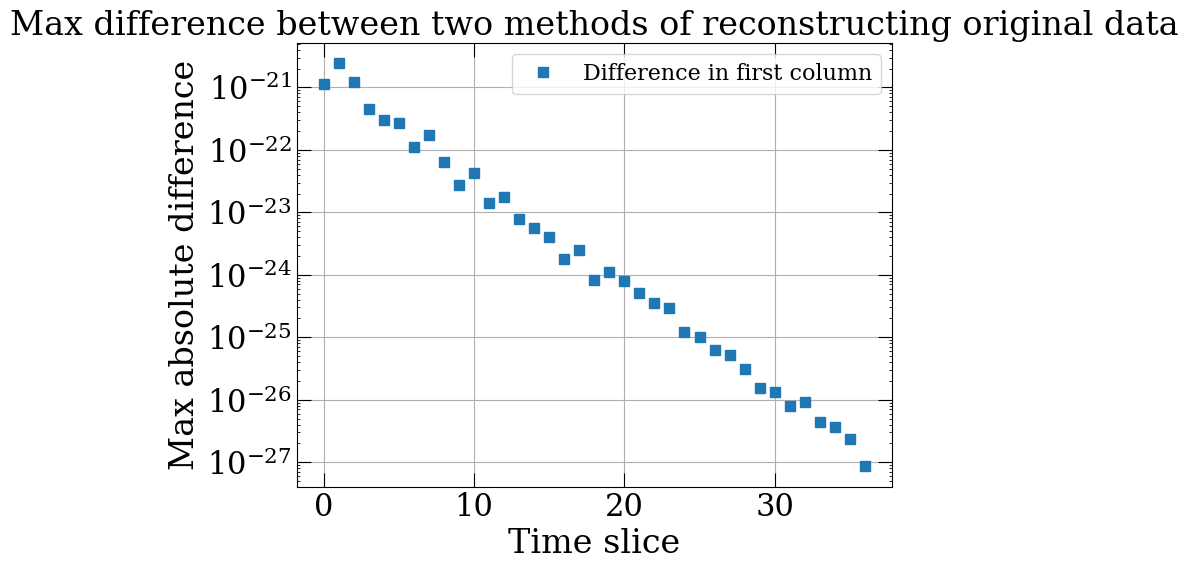

In [7]:
# import pickle
# import numpy as np
# import matplotlib.pyplot as plt

# with open('data_sgm_B64.pkl', 'rb') as f:
#     data = pickle.load(f)

# # Extract original data of two-pt functions
# c2pt_jk = data['c2pt'].astype(np.complex128)  # shape (N, N_t) — jackknife bins
N = c2pt_jk.shape[0]
jk_mean = np.mean(c2pt_jk, axis=0, dtype=np.complex128)  # overall mean
# c2pt_orig = N * jk_mean - (N - 1) * c2pt_jk  # shape (N, N_t) — original configs
c2pt_orig = jk_mean + (N - 1) * (jk_mean - c2pt_jk)  # shape (N, N_t) — original configs
c2pt_orig_old = N * jk_mean - (N - 1) * c2pt_jk  # shape (N, N_t) — original configs

diff = np.abs(c2pt_orig - c2pt_orig_old)
max_diff = np.zeros(c2pt_jk.shape[1])
for t in range(c2pt_jk.shape[1]):
    print(f"Max difference at t={t}: {diff[:,t].max()}")
    max_diff[t] = diff[:,t].max()

#plot the difference between the two methods to check if they are the same
plt.figure()
t = np.arange(c2pt_jk.shape[1])
plt.plot(t, max_diff, label='Difference in first column')
plt.xlabel('Time slice')
plt.ylabel('Max absolute difference')
plt.title('Max difference between two methods of reconstructing original data')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

In [8]:
# global parameters
ens2tminss={
        'b':[range(8,25+1),range(1,10+1),range(1,4+1)],
        'c':[range(8,29+1),range(1,16+1),range(1,5+1)],
        'd':[range(8,33+1),range(1,18+1),range(1,6+1)],
        'e':[range(8,39+1),range(1,18+1),range(1,5+1)],
    }
ens2selections={
    'b':{'1st':20,'2st':7,'3st':3},
    'c':{'1st':21,'2st':8,'3st':3},
    'd':{'1st':24,'2st':9,'3st':3},
    'e':{'1st':32,'2st':11,'3st':4},
}

ens2tminss_large={
        'b':[range(8,25+1),range(1,9+1),range(1,1+1)],
        'c':[range(8,29+1),range(1,10+1),range(1,1+1)],
        'd':[range(8,33+1),range(1,11+1),range(1,1+1)],
        'e':[range(8,39+1),range(1,13+1),range(1,1+1)],
    } # used for large momenta

In [9]:
ens2nst={'b':(39.6,1.5),'c':(39.7,1.2),'d':(38.8,2.0)}
# ens2nst={'b':(60,1.5),'c':(60,1.2),'d':(60,2.0)}

ens2DmN_lat={}
for ens in enss[:3]:
    nst=yu.jackknife_pseudo(ens2nst[ens][0],ens2nst[ens][1],ens2Njk[ens])
    amul=yu.ens2amul[ens]; amul_iso=yu.jackknife_pseudo(yu.ens2amul_iso[ens],yu.ens2amul_iso_err[ens],ens2Njk[ens])
    DmN=nst*(amul_iso-amul)/amul
    DmN=DmN[:,0]
    ens2DmN_lat[ens]=DmN
    print(yu.ens2label[ens],yu.jackme_un2str(DmN))

B64 -2.92(19)
C80 -0.90(23)
D96 -3.35(24)


In [14]:
overwrite=False
ens2DmN={'b':(-4.44,0.27),'c':(-1.44,0.24),'d':(-4.95,0.28),'e':(-0.845,0.022)}
ens2DmN={ens:yu.jackknife_pseudo(ens2DmN[ens][0],ens2DmN[ens][1],ens2Njk[ens])[:,0] for ens in enss}

mN_exp=(yu.m_proton+yu.m_neutron)/2

figs=[]; ens2pars_jk_meff1st={}; ens2pars_jk_meff2st={}; ens2pars_jk_meff3st={}
for ens in enss:
    meff=yu.jackmap(yu.c2pt2meff,ens2c2pt[ens])
    tminss=ens2tminss[ens]

    # tmins=[1.6,0.6,0.2]
    # tmins=[1.6,0.6,0.2]
    # tmins=[t*yu.ens2a['b'] for t in [20,7,3]]
    # selections={f'{i+1}st':yu.find_t_cloest(tmins[i],yu.ens2a[ens]) for i in range(3)}
    selections=ens2selections[ens]
    # selections={}
    print(ens,selections)
    
    fitss_2pt=yu.doFits_meff_nst(meff,tminss,[0.4,0.5,2,0.8,1],downSampling=1,label=f'meff_{ens}',overwrite=overwrite)
    fig,axd,result=yu.makePlot_2pt_SimoneStyle(meff,fitss_2pt,xunit=yu.ens2a[ens],yunit=yu.ens2aInv[ens]/1000,E0_ref=mN_exp/1000,ylims='std_N',\
        selection=selections)
    fig.suptitle(yu.ens2full[ens])
    yu.finalizePlot(closeQ=True)
    figs.append(fig) 
    
    ens2pars_jk_meff1st[ens]=result['1st']
    ens2pars_jk_meff2st[ens]=result['2st']
    ens2pars_jk_meff3st[ens]=result['3st']

enss=['b','c','d','e']

ens2dats=[{ens:ens2pars_jk_meffnst[ens][:,0]*yu.ens2aInv[ens] for ens in enss} for ens2pars_jk_meffnst in [ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]]
fitss=[yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yuc.lat_a2s_plt) for ens2dat in ens2dats]
matrix_dic=[{
    'ens2dat':ens2dats[ist],
    'fit:[fits,lat_a2s_plt]':[fitss[ist],yuc.lat_a2s_plt]
    } for ist in range(len(ens2dats))]
fig,axs=yu.makePlot_continuumExtrapolation(matrix_dic,shows=['MA'])
yu.addColHeader(axs,['1st','2st','3st'])
ax=axs[0,0]
ax.set_ylim([920,960])
ax.set_ylabel(r'$m_N$ [MeV]')
for icol in range(len(matrix_dic)):
    ax=axs[0,icol]
    yu.addRefLine(ax,mN_exp,label=r'$m_N^{\mathrm{exp}}=$'+'%0.3f'%mN_exp)
    ax.legend(fontsize=16)  
yu.finalizePlot(closeQ=True)
figs.append(fig)

# ens2dats=[{ens:ens2pars_jk_meffnst[ens][:,0]*yu.ens2aInv[ens]+ens2DmN_lat[ens] for ens in enss} for ens2pars_jk_meffnst in [ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]]
# fitss=[yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yuc.lat_a2s_plt) for ens2dat in ens2dats]
# matrix_dic=[{
#     'ens2dat':ens2dats[ist],
#     'fit:[fits,lat_a2s_plt]':[fitss[ist],yuc.lat_a2s_plt]
#     } for ist in range(len(ens2dats))]
# fig,axs=yu.makePlot_continuumExtrapolation(matrix_dic,shows=['MA'])
# yu.addColHeader(axs,['1st','2st','3st'])
# ax=axs[0,0]
# ax.set_ylim([920,960])
# ax.set_ylabel(r'$m_N$ [MeV]')
# for icol in range(len(matrix_dic)):
#     ax=axs[0,icol]
#     yu.addRefLine(ax,mN_exp,label=r'$m_N^{\mathrm{exp}}=$'+'%0.3f'%mN_exp)
#     ax.legend(fontsize=16)  
# fig.suptitle(r'corrected using lattice $\sigma_{\pi N}$')
# yu.finalizePlot(closeQ=True)
# figs.append(fig)

ens2dats=[{ens:ens2pars_jk_meffnst[ens][:,0]*yu.ens2aInv[ens]+ens2DmN[ens] for ens in enss} for ens2pars_jk_meffnst in [ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]]
fitss=[yu.doFits_continuumExtrapolation(ens2dat,lat_a2s_plt=yuc.lat_a2s_plt) for ens2dat in ens2dats]
matrix_dic=[{
    'ens2dat':ens2dats[ist],
    'fit:[fits,lat_a2s_plt]':[fitss[ist],yuc.lat_a2s_plt]
    } for ist in range(len(ens2dats))]
fig,axs=yu.makePlot_continuumExtrapolation(matrix_dic,shows=['MA'])
yu.addColHeader(axs,['1st','2st','3st'])
ax=axs[0,0]
ax.set_ylim([920,960])
ax.set_ylabel(r'$m_N$ [MeV]')
for icol in range(len(matrix_dic)):
    ax=axs[0,icol]
    yu.addRefLine(ax,mN_exp,label=r'$m_N^{\mathrm{exp}}=$'+'%0.3f'%mN_exp)
    ax.legend(fontsize=16)  
fig.suptitle(r'corrected using $O(p^3)$ ChPT')
yu.finalizePlot(closeQ=True)
figs.append(fig)

enss=['b','c','d','e']
    
yu.makePDF('meff',figs)

label=f'ens2pars_jk_meffnst_selected'
yu.save_pkl_reg(label,[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st])

b {'1st': 20, '2st': 7, '3st': 3}


c {'1st': 21, '2st': 8, '3st': 3}
d {'1st': 24, '2st': 9, '3st': 3}
e {'1st': 32, '2st': 11, '3st': 4}
